<a href="https://colab.research.google.com/github/deivinso1987/Repositorio-importado/blob/master/Segundo_Informe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cargamos las librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Generamos el conjunto de datos

In [4]:
np.random.seed(42)

n = 120

data = pd.DataFrame({
    "ID": range(1, n+1),
    "Edad": np.random.randint(18, 65, n),
    "Estatura": np.random.normal(170, 10, n).round(1),  # cm
    "Peso": np.random.normal(70, 15, n).round(1),       # kg
    "Nivel_Actividad": np.random.choice(["Sedentario", "Moderado", "Activo"], n),
    "Frecuencia_Cardiaca": np.random.randint(55, 90, n),
    "Horas_Sueño": np.random.normal(7, 1.2, n).round(1)
})

# Creamos la variable IMC
data["IMC"] = (data["Peso"] / ((data["Estatura"]/100)**2)).round(2)

print(data.head())

   ID  Edad  Estatura   Peso Nivel_Actividad  Frecuencia_Cardiaca  \
0   1    56     182.1  104.1        Moderado                   79   
1   2    46     182.3   72.2      Sedentario                   87   
2   3    32     154.3   78.1      Sedentario                   60   
3   4    60     176.4   47.5          Activo                   86   
4   5    25     149.6   69.8      Sedentario                   75   

   Horas_Sueño    IMC  
0          6.8  31.39  
1          8.7  21.73  
2          7.6  32.80  
3          7.7  15.26  
4          5.2  31.19  


# Distribución de Probabilidad

### Determina si las variables siguen una distribución normal mediante una prueba de bondad y ajuste Chi cuadrado.

In [5]:
from scipy.stats import norm, chi2

# FUNCIÓN CHI-CUADRADO PARA NORMALIDAD

def chi_normalidad(variable, alpha=0.05):

    x = variable.dropna().values
    n = len(x)

    # Número de clases (Sturges)
    k = int(1 + 3.322 * np.log10(n))

    # Parámetros estimados
    mu = np.mean(x)
    sigma = np.std(x, ddof=1)

    # Límites de clases
    limites = np.linspace(np.min(x), np.max(x), k + 1)

    # Frecuencia observada
    fo, _ = np.histogram(x, bins=limites)

     # Frecuencia esperada
    fe = []

    for i in range(len(limites) - 1):
        p = norm.cdf(limites[i+1], mu, sigma) - norm.cdf(limites[i], mu, sigma)
        fe.append(p * n)

    fe = np.array(fe)

    # Unir clases con frecuencia esperada < 5
    tabla = pd.DataFrame({"fo": fo, "fe": fe})
    tabla = tabla[tabla["fe"] >= 5]

    fo = tabla["fo"].values
    fe = tabla["fe"].values

     # Estadístico
    chi_calc = np.sum((fo - fe)**2 / fe)

    # grados libertad
    gl = len(fe) - 1 - 2

    chi_critico = chi2.ppf(1 - alpha, gl)

    if chi_calc < chi_critico:
        conclusion = "No se rechaza H0 (Normal)"
    else:
        conclusion = "Se rechaza H0 (No normal)"

    return {
        "Variable": variable.name,
        "Chi calculado": round(chi_calc,4),
        "Chi crítico": round(chi_critico,4),
        "GL": gl,
        "Conclusión": conclusion
    }

# ==========================================================
# VARIABLES NUMÉRICAS A EVALUAR
# ==========================================================
variables = [
    "Edad",
    "Estatura",
    "Peso",
    "Frecuencia_Cardiaca",
    "Horas_Sueño",
    "IMC"
]

resultados = []

for var in variables:
    resultados.append(chi_normalidad(data[var]))

resultado_final = pd.DataFrame(resultados)

print(resultado_final)

              Variable  Chi calculado  Chi crítico  GL  \
0                 Edad        32.3320       9.4877   4   
1             Estatura         2.2635       7.8147   3   
2                 Peso         4.1504       7.8147   3   
3  Frecuencia_Cardiaca        32.5053       9.4877   4   
4          Horas_Sueño         9.5672       9.4877   4   
5                  IMC         1.2433       7.8147   3   

                  Conclusión  
0  Se rechaza H0 (No normal)  
1  No se rechaza H0 (Normal)  
2  No se rechaza H0 (Normal)  
3  Se rechaza H0 (No normal)  
4  Se rechaza H0 (No normal)  
5  No se rechaza H0 (Normal)  


# Probabilidades y Eventos

## Calcula la probabilidad de que una persona tenga una edad mayor a la media del conjunto de datos

In [6]:
# Media de edades
media_edad = data["Edad"].mean()

# Número de personas con edad mayor a la media
casos_favorables = (data["Edad"] > media_edad).sum()

# Total de personas
total = len(data)

# Probabilidad empírica
probabilidad = casos_favorables / total

# ==========================================================
# RESULTADOS
# ==========================================================
print("Media de Edad:", round(media_edad,2))
print("Personas con edad mayor a la media:", casos_favorables)
print("Total de personas:", total)
print("Probabilidad:", round(probabilidad,4))
print("Probabilidad (%):", round(probabilidad*100,2), "%")

Media de Edad: 40.67
Personas con edad mayor a la media: 61
Total de personas: 120
Probabilidad: 0.5083
Probabilidad (%): 50.83 %


## Determina la probabilidad de que una persona tenga una estatura dentro de un intervalo definido por la media y una desviación estándar.


In [7]:
# Media y desviación estándar
media = data["Estatura"].mean()
desv = data["Estatura"].std()

# Intervalo [μ - σ , μ + σ]
lim_inf = media - desv
lim_sup = media + desv

# Casos favorables
casos = data[
    (data["Estatura"] >= lim_inf) &
    (data["Estatura"] <= lim_sup)
].shape[0]

# Total
total = len(data)

# Probabilidad empírica
probabilidad = casos / total

# ==========================================================
# RESULTADOS
# ==========================================================
print("Media estatura:", round(media,2))
print("Desviación estándar:", round(desv,2))
print("Intervalo:", round(lim_inf,2), "a", round(lim_sup,2))
print("Personas dentro del intervalo:", casos)
print("Total personas:", total)
print("Probabilidad:", round(probabilidad,4))
print("Probabilidad (%):", round(probabilidad*100,2), "%")

Media estatura: 169.62
Desviación estándar: 10.05
Intervalo: 159.57 a 179.67
Personas dentro del intervalo: 85
Total personas: 120
Probabilidad: 0.7083
Probabilidad (%): 70.83 %


# Intervalos de Confianza

Calcula un intervalo de confianza del 95% para la media de la variable Edad y para la variable Estatura.

Interpreta los resultados en términos de incertidumbre y variabilidad de los datos.

In [11]:
from scipy.stats import t

# ==========================================================
# FUNCIÓN INTERVALO DE CONFIANZA 95%
# ==========================================================
def intervalo_confianza(variable, confianza=0.95):

    x = data[variable]
    n = len(x)
    media = np.mean(x)
    s = np.std(x, ddof=1)

    alpha = 1 - confianza
    t_critico = t.ppf(1 - alpha/2, df=n-1)

    error = t_critico * (s / np.sqrt(n))

    li = media - error
    ls = media + error

    return {
        "Variable": variable,
        "Media": round(media,4),
        "Desv.Est": round(s,4),
        "IC 95% Inferior": round(li,4),
        "IC 95% Superior": round(ls,4),
        "Margen Error": round(error,4)
    }

# ==========================================================
# CALCULAR IC
# ==========================================================
res_edad = intervalo_confianza("Edad")
res_estatura = intervalo_confianza("Estatura")

resultado = pd.DataFrame([res_edad, res_estatura])

print(resultado)


   Variable     Media  Desv.Est  IC 95% Inferior  IC 95% Superior  \
0      Edad   40.6667   13.8208          38.1685          43.1649   
1  Estatura  169.6183   10.0507         167.8016         171.4351   

   Margen Error  
0        2.4982  
1        1.8167  


INTERPRETACIÓN

## Edad:

Con 95% de confianza, la media poblacional de la edad se encuentra entre
38.1685 y 43.1649 años.


## Estatura:

Con 95% de confianza, la media poblacional de la estatura se encuentra entre
167.8016 y 171.4351 cm.


Un intervalo más estrecho indica menor incertidumbre en la estimación.
Mayor desviación estándar implica mayor variabilidad en los datos.


# Modelo de Regresión Lineal
## Construcción del Modelo:

### Plantea un modelo de regresión lineal simple donde Estatura sea la variable dependiente y Edad la variable independiente.

### Ajusta el modelo usando la librería scikit-learn y muestra los coeficientes obtenidos.

In [12]:
from sklearn.linear_model import LinearRegression

X = data[["Edad"]]          # predictor(Variable Independiente)
y = data["Estatura"]        # respuesta(Variable Dependiente)

# Crear modelo
modelo = LinearRegression()

# Ajustar modelo
modelo.fit(X, y)

# Coeficientes
beta0 = modelo.intercept_
beta1 = modelo.coef_[0]

# R²
r2 = modelo.score(X, y)

# ==========================================================
# RESULTADOS
# ==========================================================
print("MODELO AJUSTADO")
print("Estatura = β0 + β1(Edad)\n")

print("Intercepto (β0):", round(beta0,4))
print("Pendiente  (β1):", round(beta1,4))
print("R²:", round(r2,4))

print("\nEcuación estimada:")
print(f"Estatura = {round(beta0,4)} + ({round(beta1,4)})*Edad")

MODELO AJUSTADO
Estatura = β0 + β1(Edad)

Intercepto (β0): 170.0376
Pendiente  (β1): -0.0103
R²: 0.0002

Ecuación estimada:
Estatura = 170.0376 + (-0.0103)*Edad


# Evaluación del Modelo:

## Calcula el coeficiente de determinación (R²) e interpreta qué tan bien se ajusta el modelo a los datos.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = data[["Edad"]]
y = data["Estatura"]

modelo = LinearRegression()
modelo.fit(X, y)

# Predicciones
y_pred = modelo.predict(X)

# Coeficiente de determinación
r2 = r2_score(y, y_pred)

# ==========================================================
# RESULTADOS
# ==========================================================
print("Coeficiente de determinación R² =", round(r2,4))

# Interpretación automática
if r2 < 0.30:
    ajuste = "débil"
elif r2 < 0.60:
    ajuste = "moderado"
else:
    ajuste = "fuerte"

print(f"""
Interpretación:
El modelo explica aproximadamente {round(r2*100,2)}% de la variabilidad
de la variable Estatura a partir de la Edad.

Por tanto, el ajuste del modelo es {ajuste}.
""")

Coeficiente de determinación R² = 0.0002

Interpretación:
El modelo explica aproximadamente 0.02% de la variabilidad
de la variable Estatura a partir de la Edad.

Por tanto, el ajuste del modelo es débil.



# Representa gráficamente la recta de regresión junto con los datos originales en un diagrama de dispersión.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


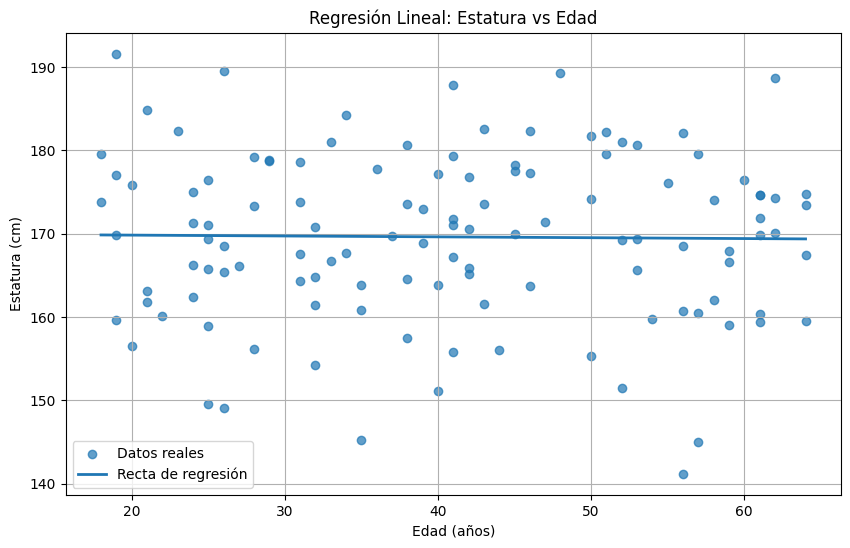

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# ==========================================================
# VARIABLES
# ==========================================================
X = data[["Edad"]]
y = data["Estatura"]

# ==========================================================
# MODELO DE REGRESIÓN
# ==========================================================
modelo = LinearRegression()
modelo.fit(X, y)

# Predicciones
x_linea = np.linspace(data["Edad"].min(), data["Edad"].max(), 100).reshape(-1,1)
y_linea = modelo.predict(x_linea)

# ==========================================================
# GRÁFICA
# ==========================================================
plt.figure(figsize=(10,6))

# Datos originales
plt.scatter(data["Edad"], data["Estatura"], alpha=0.7, label="Datos reales")

# Recta de regresión
plt.plot(x_linea, y_linea, linewidth=2, label="Recta de regresión")

# Etiquetas
plt.title("Regresión Lineal: Estatura vs Edad")
plt.xlabel("Edad (años)")
plt.ylabel("Estatura (cm)")
plt.legend()
plt.grid(True)

plt.show()

# Predicción:

## Usa el modelo para predecir la estatura de una persona con una edad específica y analiza la confiabilidad de la predicción.

In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==========================================================
# REGRESIÓN LINEAL SIMPLE
# Estatura = f(Edad)
# ==========================================================
X = data[["Edad"]]
y = data["Estatura"]

modelo = LinearRegression()
modelo.fit(X, y)

# ==========================================================
# PREDICCIÓN
# Cambiar edad_pred por la edad deseada
# ==========================================================
edad_pred = 30

estatura_pred = modelo.predict([[edad_pred]])[0]

# ==========================================================
# R² DEL MODELO
# ==========================================================
y_pred = modelo.predict(X)
r2 = r2_score(y, y_pred)

# ==========================================================
# RESULTADOS
# ==========================================================
print("Edad evaluada:", edad_pred, "años")
print("Estatura estimada:", round(estatura_pred,2), "cm")
print("R² del modelo:", round(r2,4))

# ==========================================================
# INTERPRETACIÓN DE CONFIABILIDAD
# ==========================================================
if r2 < 0.30:
    confiabilidad = "BAJA"
elif r2 < 0.60:
    confiabilidad = "MODERADA"
else:
    confiabilidad = "ALTA"

print(f"""
Interpretación:
Para una persona de {edad_pred} años, el modelo estima una estatura de
{round(estatura_pred,2)} cm.

La confiabilidad de la predicción es {confiabilidad},
porque el modelo explica aproximadamente {round(r2*100,2)}%
de la variabilidad de la estatura.
""")

Edad evaluada: 30 años
Estatura estimada: 169.73 cm
R² del modelo: 0.0002

Interpretación:
Para una persona de 30 años, el modelo estima una estatura de
169.73 cm.

La confiabilidad de la predicción es BAJA,
porque el modelo explica aproximadamente 0.02%
de la variabilidad de la estatura.



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
